# Deep Neural Network Application - Transport Dataset
Binary Classification: Car (1) vs Bike (0)
Dataset path:
`transport/cars/`
`transport/bike/`


In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## Load Dataset

In [2]:

def load_images(folder, label, size=(64,64)):
    X, Y = [], []
    for file in os.listdir(folder):
        if file.endswith(".bmp"):
            path = os.path.join(folder, file)
            img = Image.open(path).convert("RGB")
            img = img.resize(size)
            X.append(np.array(img))
            Y.append(label)
    return X, Y

base_path = "transport"
cars_path = os.path.join(base_path, "cars")
bike_path = os.path.join(base_path, "bike")

X_cars, Y_cars = load_images(cars_path, 1)
X_bike, Y_bike = load_images(bike_path, 0)

X = np.array(X_cars + X_bike)
Y = np.array(Y_cars + Y_bike)

m = X.shape[0]
X = X.reshape(m, -1).T / 255.
Y = Y.reshape(1, m)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (12288, 785)
Y shape: (1, 785)


## Helper Functions

In [3]:

def sigmoid(Z):
    return 1/(1+np.exp(-Z)), Z

def relu(Z):
    return np.maximum(0,Z), Z

def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z<=0] = 0
    return dZ

def sigmoid_backward(dA, cache):
    Z = cache
    s = 1/(1+np.exp(-Z))
    return dA*s*(1-s)


In [4]:

def initialize_parameters_deep(layer_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layer_dims)
    
    for l in range(1, L):
        parameters['W'+str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        parameters['b'+str(l)] = np.zeros((layer_dims[l],1))
        
    return parameters


In [5]:

def forward_propagation(X, parameters):
    caches = []
    A = X
    L = len(parameters)//2
    
    for l in range(1, L):
        A_prev = A
        Z = np.dot(parameters['W'+str(l)], A_prev) + parameters['b'+str(l)]
        A, cache = relu(Z)
        caches.append((A_prev, parameters['W'+str(l)], parameters['b'+str(l)], Z))
    
    ZL = np.dot(parameters['W'+str(L)], A) + parameters['b'+str(L)]
    AL, cache = sigmoid(ZL)
    caches.append((A, parameters['W'+str(L)], parameters['b'+str(L)], ZL))
    
    return AL, caches


In [6]:

def compute_cost(AL, Y):
    m = Y.shape[1]
    return -1/m * np.sum(Y*np.log(AL) + (1-Y)*np.log(1-AL))


In [7]:

def backward_propagation(AL, Y, caches):
    grads = {}
    L = len(caches)
    m = AL.shape[1]
    
    dAL = -(np.divide(Y, AL) - np.divide(1-Y, 1-AL))
    
    current_cache = caches[L-1]
    A_prev, W, b, Z = current_cache
    dZ = sigmoid_backward(dAL, Z)
    grads["dW"+str(L)] = 1/m * np.dot(dZ, A_prev.T)
    grads["db"+str(L)] = 1/m * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        A_prev, W, b, Z = current_cache
        dZ = relu_backward(dA_prev, Z)
        grads["dW"+str(l+1)] = 1/m * np.dot(dZ, A_prev.T)
        grads["db"+str(l+1)] = 1/m * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = np.dot(W.T, dZ)
    
    return grads


In [8]:

def update_parameters(parameters, grads, learning_rate):
    L = len(parameters)//2
    for l in range(1, L+1):
        parameters["W"+str(l)] -= learning_rate * grads["dW"+str(l)]
        parameters["b"+str(l)] -= learning_rate * grads["db"+str(l)]
    return parameters


In [9]:

def L_layer_model(X, Y, layers_dims, learning_rate=0.0075, num_iterations=500):
    
    parameters = initialize_parameters_deep(layers_dims)
    
    for i in range(num_iterations):
        AL, caches = forward_propagation(X, parameters)
        cost = compute_cost(AL, Y)
        grads = backward_propagation(AL, Y, caches)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 100 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
            
    return parameters


## Train Model 

In [10]:

layers_dims = [X.shape[0], 20, 7, 5, 1]

parameters = L_layer_model(X, Y, layers_dims, num_iterations=500)

AL, _ = forward_propagation(X, parameters)
predictions = (AL > 0.5)

accuracy = np.mean(predictions == Y) * 100
print("Training Accuracy:", accuracy, "%")


Cost after iteration 0: 0.6931462112156536
Cost after iteration 100: 0.6923778444037035
Cost after iteration 200: 0.6918499932260649
Cost after iteration 300: 0.6914873507464763
Cost after iteration 400: 0.6912381690228562
Training Accuracy: 53.503184713375795 %


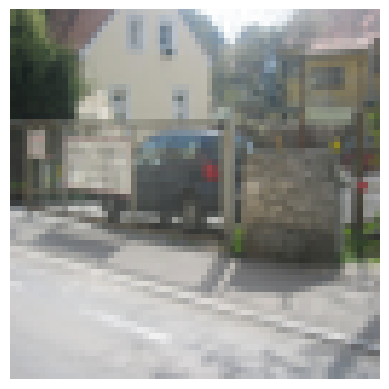

Probability: 0.5213237064807713
Prediction: Car (1)


In [12]:
# Test a single image (change path as needed)
test_path = "transport/cars/carsgraz_002.bmp"   # or transport/bike/filename.bmp

img = Image.open(test_path).convert("RGB")
img = img.resize((64, 64))
img_array = np.array(img)

plt.imshow(img)
plt.axis("off")
plt.show()

x = img_array.reshape(1, -1).T / 255.
AL, _ = forward_propagation(x, parameters)

print("Probability:", float(AL[0, 0]))

if AL[0, 0] > 0.5:
    print("Prediction: Car (1)")
else:
    print("Prediction: Bike (0)")